# Building a Multi-Class Classification Model

- input shape = 28 x 28 (the shape of one image)
- output shape = 10 (one per class of clothing)
- loss function = tf.keras.losses.CategoricalCrossentropy()
- output layer activation = Softmax (not sigmoid)

In [16]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [17]:
tf.__version__

'2.19.1'

In [3]:
# data has already been sorted in training and testing datasets
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [4]:
# check the data
train_data[0], train_labels[0]

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
           0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
           1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
           0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
           0,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
           0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
          10

In [5]:
# check the shape
train_data[0].shape, train_labels[0].shape

((28, 28), ())

In [6]:
import matplotlib.pyplot as plt

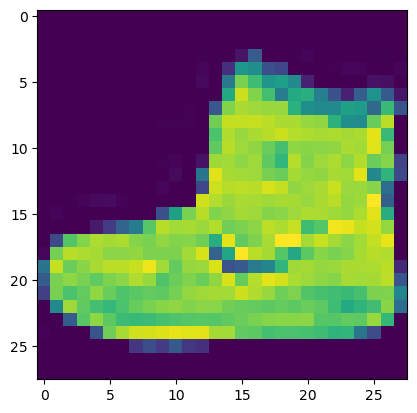

In [7]:
# plot a single data
plt.imshow(train_data[0])

In [8]:
# check the label
train_labels[0]

9

In [9]:
# create a index labels
class_names = ["T-shirts/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

In [10]:
len(class_names), class_names[train_labels[0]]

(10, 'Ankle Boot')

In [11]:
# check the min and max values of the training data
train_data.min(), train_data.max()

(0, 255)

In [12]:
# normalized the data between 0 and 1 values
data_max_value = train_data.max()
train_data_norm = train_data / data_max_value # 255.0
test_data_norm = test_data / data_max_value # 255.0

# check the values of normalized data
train_data_norm.min(), test_data_norm.max()

(0.0, 1.0)

In [19]:
tf.random.set_seed(42)

# create the model
total_classes = len(class_names)
model = tf.keras.models.Sequential([
    # Flatten the 28x28 image into a 1D array
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    # First hidden layer with 128 neurons
    tf.keras.layers.Dense(128, activation="relu"),

    # Second hidden layer with 64 neurons
    tf.keras.layers.Dense(64, activation="relu"),

    # Output layer with 10 neurons (one per class)
    tf.keras.layers.Dense(total_classes, activation=tf.keras.activations.softmax)
])

# compile the model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             metrics=["accuracy"])

# learning rate callback
enabled_learning_rate_callback = False
if enabled_learning_rate_callback: 
    lrt_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 ** (epoch/20))

epoch = 25
if enabled_learning_rate_callback:
    # fit the model
    history = model.fit(train_data_norm,
                        train_labels,
                        epochs=epoch,
                        validation_data=(test_data_norm, test_labels),
                        callbacks=lrt_callback)
else:
    # fit the model
    history = model.fit(train_data_norm,
                        train_labels,
                        epochs=epoch,
                        validation_data=(test_data_norm, test_labels))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7709 - loss: 0.6474 - val_accuracy: 0.8540 - val_loss: 0.4071
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8606 - loss: 0.3813 - val_accuracy: 0.8607 - val_loss: 0.3824
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8749 - loss: 0.3383 - val_accuracy: 0.8640 - val_loss: 0.3728
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8822 - loss: 0.3112 - val_accuracy: 0.8668 - val_loss: 0.3632
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8897 - loss: 0.2909 - val_accuracy: 0.8678 - val_loss: 0.3571
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8956 - loss: 0.2762 - val_accuracy: 0.8691 - val_loss: 0.3578
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9022 - loss: 0.2603 - val_accuracy: 0.8706 - val_loss: 0.3588
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9035 - loss: 0.2516 - 

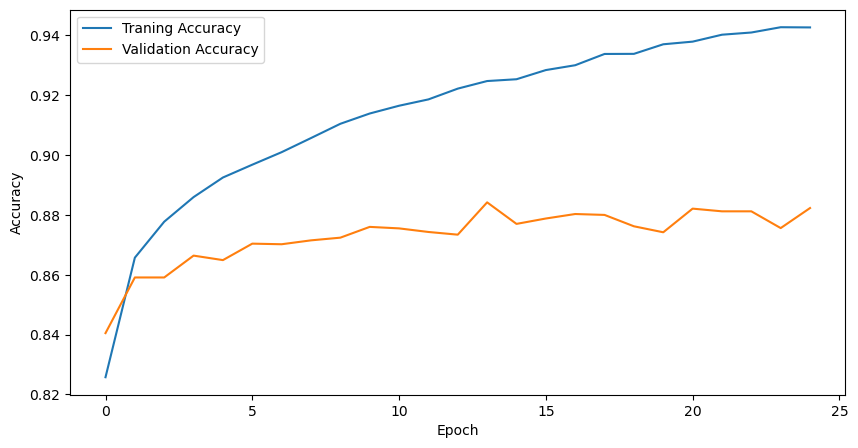

In [14]:
# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
if enabled_learning_rate_callback:
    lrs = 1e-4 * (10 ** (tf.range(epoch) / 12))
    plt.figure(figsize=(10, 7))
    plt.semilogx(lrs, history.history["loss"]) # used for creating line plots where the x-axis is scaled logarithmically (base-10 by default), while the y-axis remains linear (arithmetic scale)
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning Rate vs Loss")

### Evaluating Multi-Class Classification Model

In [28]:
y_preds = model.predict(test_data_norm)
y_preds = y_preds.argmax(axis=1) # convert to integer
y_preds[:3], class_names[y_preds[0]] # check the prediction class name

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   


(array([9, 2, 1]), 'Ankle Boot')

In [38]:
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

In [39]:
confusion_matrix(y_true=test_labels,
                y_pred=y_preds)

array([[840,   9,  14,  19,   4,   1, 103,   0,  10,   0],
       [  0, 986,   2,   3,   3,   0,   4,   0,   2,   0],
       [ 20,   5, 821,   9,  92,   1,  50,   0,   2,   0],
       [ 22,  23,  13, 829,  58,   0,  50,   0,   5,   0],
       [  1,   4,  96,  12, 858,   0,  27,   0,   2,   0],
       [  0,   0,   0,   0,   0, 952,   0,  29,   1,  18],
       [122,   5,  96,  22, 115,   1, 627,   0,  12,   0],
       [  0,   0,   0,   0,   0,   8,   0, 978,   0,  14],
       [  3,   1,   4,   4,   6,   2,   4,   4, 972,   0],
       [  1,   0,   0,   0,   0,   7,   0,  63,   0, 929]])

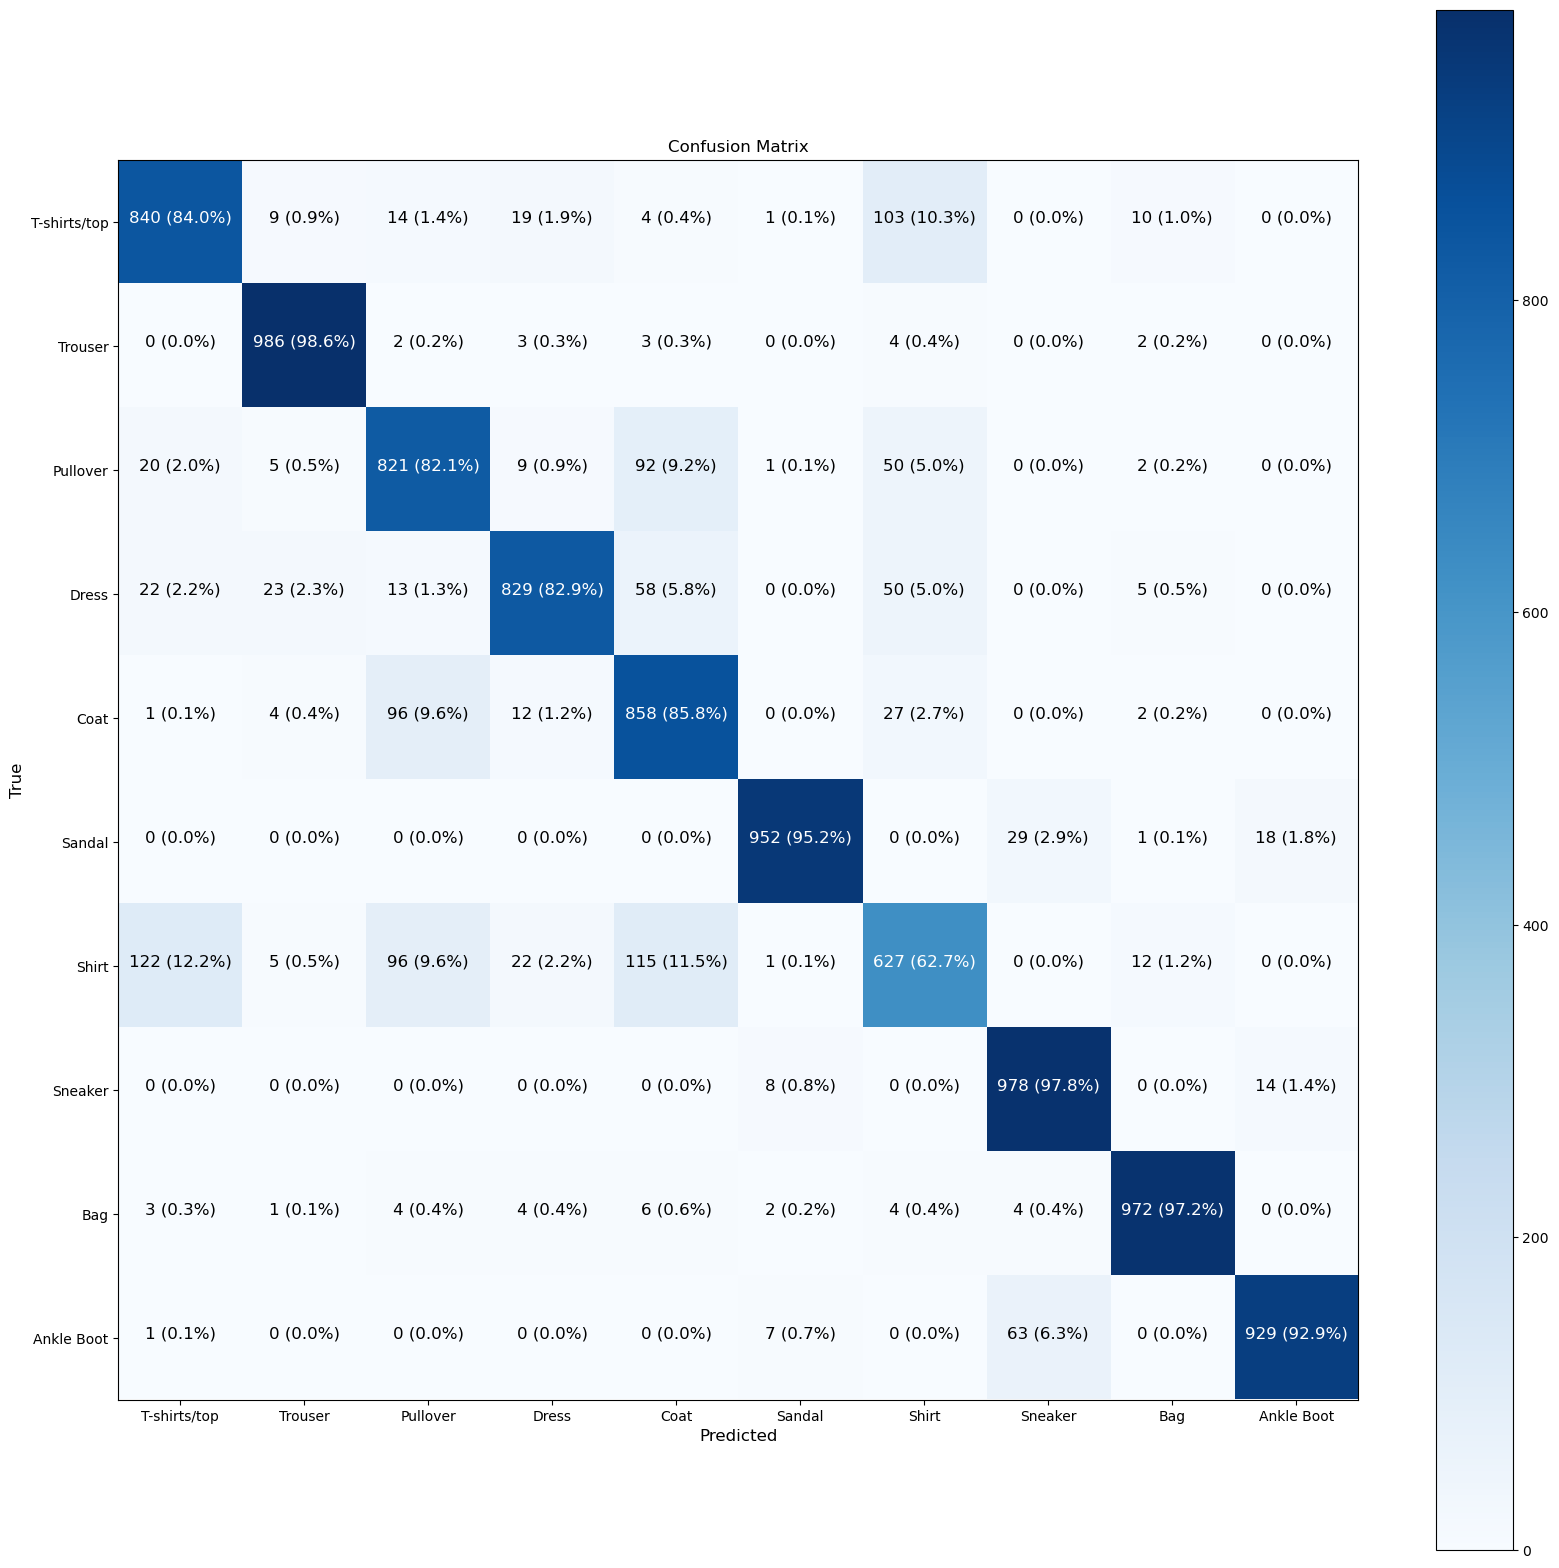

In [50]:
figsize = (20, 20)

# create the confusion matrix
cm = confusion_matrix(test_labels, y_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize our confusion matrix
n_classes = cm.shape[0]

# prettify it
fig, ax = plt.subplots(figsize=figsize)
# create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# create classes
labels = class_names

# label the axes
ax.set(title="Confusion Matrix",
      xlabel="Predicted",
      ylabel="True",
      xticks=np.arange(n_classes),
      yticks=np.arange(n_classes),
      xticklabels=labels,
      yticklabels=labels)

# set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# adjust label size
ax.yaxis.label.set_size(12)
ax.xaxis.label.set_size(12)
ax.title.set_size(12)

# set threshold for different colors
threshold = (cm.max() + cm.min()) / 2

# plot the test on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j] * 100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=12)

In [62]:
### Plot Random Image
import random

def plot_random_image(model, images, true_labels, classes):
    """
    Picks a random image, plots it and labels it with a prediction and truth label
    """
    # set up random integer
    i = random.randint(0, len(images))

    # create predictions and targets
    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]

    # plot the image
    plt.imshow(target_image, cmap=plt.cm.binary)

    # change the color of the titles depending on if the prediction is right or wrong
    if pred_label == true_label:
        color = "green"
    else:
        color = "red"

    # add xlabel infromation (prediction/true label)
    plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                    100*tf.reduce_max(pred_probs),
                                                    true_label),
              color=color) # set the color based on prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


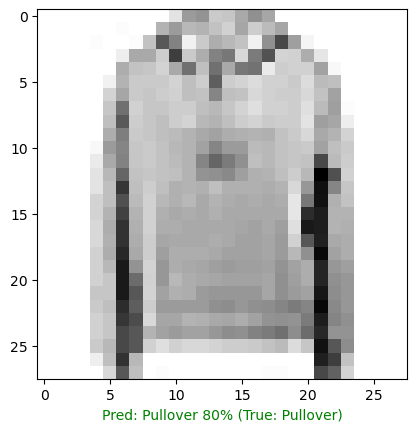

In [81]:
# check out a random image
plot_random_image(model=model,
                 images=test_data_norm,
                 true_labels=test_labels,
                 classes=class_names)

### What Patterns is our Model Learning?

In [82]:
# find the layers of our most recent model
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [83]:
# extract a particular layer
model.layers[1]

<Dense name=dense_3, built=True>

In [85]:
# get the patterns of a layer in our network
weights, biases = model.layers[1].get_weights()

# shapes
weights, weights.shape

(array([[-0.06378838, -0.6730902 , -0.6537191 , ..., -0.3266796 ,
         -0.46262658, -0.20578577],
        [ 0.30283496, -0.0393252 ,  0.28092545, ...,  0.13511273,
         -0.74704164,  0.1856781 ],
        [ 0.65328896, -0.2200127 ,  1.2476758 , ...,  0.0179827 ,
         -0.61987436,  0.47390944],
        ...,
        [-0.17920728,  0.0568451 , -0.512722  , ...,  0.03487363,
          0.04759505, -0.6027273 ],
        [ 0.4129499 , -0.00349835,  0.20084524, ...,  0.6886573 ,
          0.9866757 , -0.34042165],
        [ 0.4793095 ,  0.17849895, -0.07264941, ...,  0.48314592,
          0.00676582, -0.30362898]], dtype=float32),
 (784, 128))

In [86]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

### Checking Out the Bias Vector

**Bias Vector**
- A bias vector is just a list of bias values—one per neuron in a layer.
- It helps neurons learn better by letting them shift their output.
- It's automatically handled when you use layers in TensorFlow like Dense.

**What are weights in a neural network?**

Think of a neural network as a **smart calculator** trying to figure out patterns in data—like recognizing digits, predicting prices, or translating languages.

Every connection between inputs and neurons has a weight, which is a number that tells the neuron:

> "How important is this input?"

**Why are weights important?**

- Weights are what the neural network learns!
- When training a model, TensorFlow changes the weights (and biases) to make predictions more accurate.
- Think of weights as dials the network adjusts to get the correct answer.

In [88]:
biases, biases.shape

(array([-2.97526643e-02,  5.51447988e-01, -2.11021900e-01, -1.71971008e-01,
         8.93631816e-01,  3.58277678e-01,  2.98459917e-01,  3.10455620e-01,
         4.82311249e-01, -1.18613422e-01,  5.02351165e-01, -1.04545698e-01,
         2.17383146e-01, -2.76711974e-02,  3.62627536e-01, -1.06795263e-02,
        -2.41449326e-02,  4.40060832e-02, -1.68327913e-01, -5.68398051e-02,
         2.30657592e-01, -5.84993243e-01,  4.06510055e-01, -4.31438655e-01,
        -1.50096908e-01,  2.86223173e-01,  4.99438614e-01,  5.37865996e-01,
         2.77986139e-01, -1.87557280e-01,  7.55050004e-01,  3.05756271e-01,
         2.57006794e-01,  6.42360568e-01,  3.82372886e-01,  5.10203242e-02,
        -3.39296192e-01,  5.19422650e-01,  7.23094270e-02,  5.69532037e-01,
        -4.49778419e-03, -2.80051548e-02,  3.51038396e-01,  6.49878681e-01,
        -1.45726725e-01, -4.94782478e-01, -1.88662261e-01,  5.78185558e-01,
         2.57562518e-01,  3.41638625e-01, -5.19924521e-01,  4.29394215e-01,
         1.9

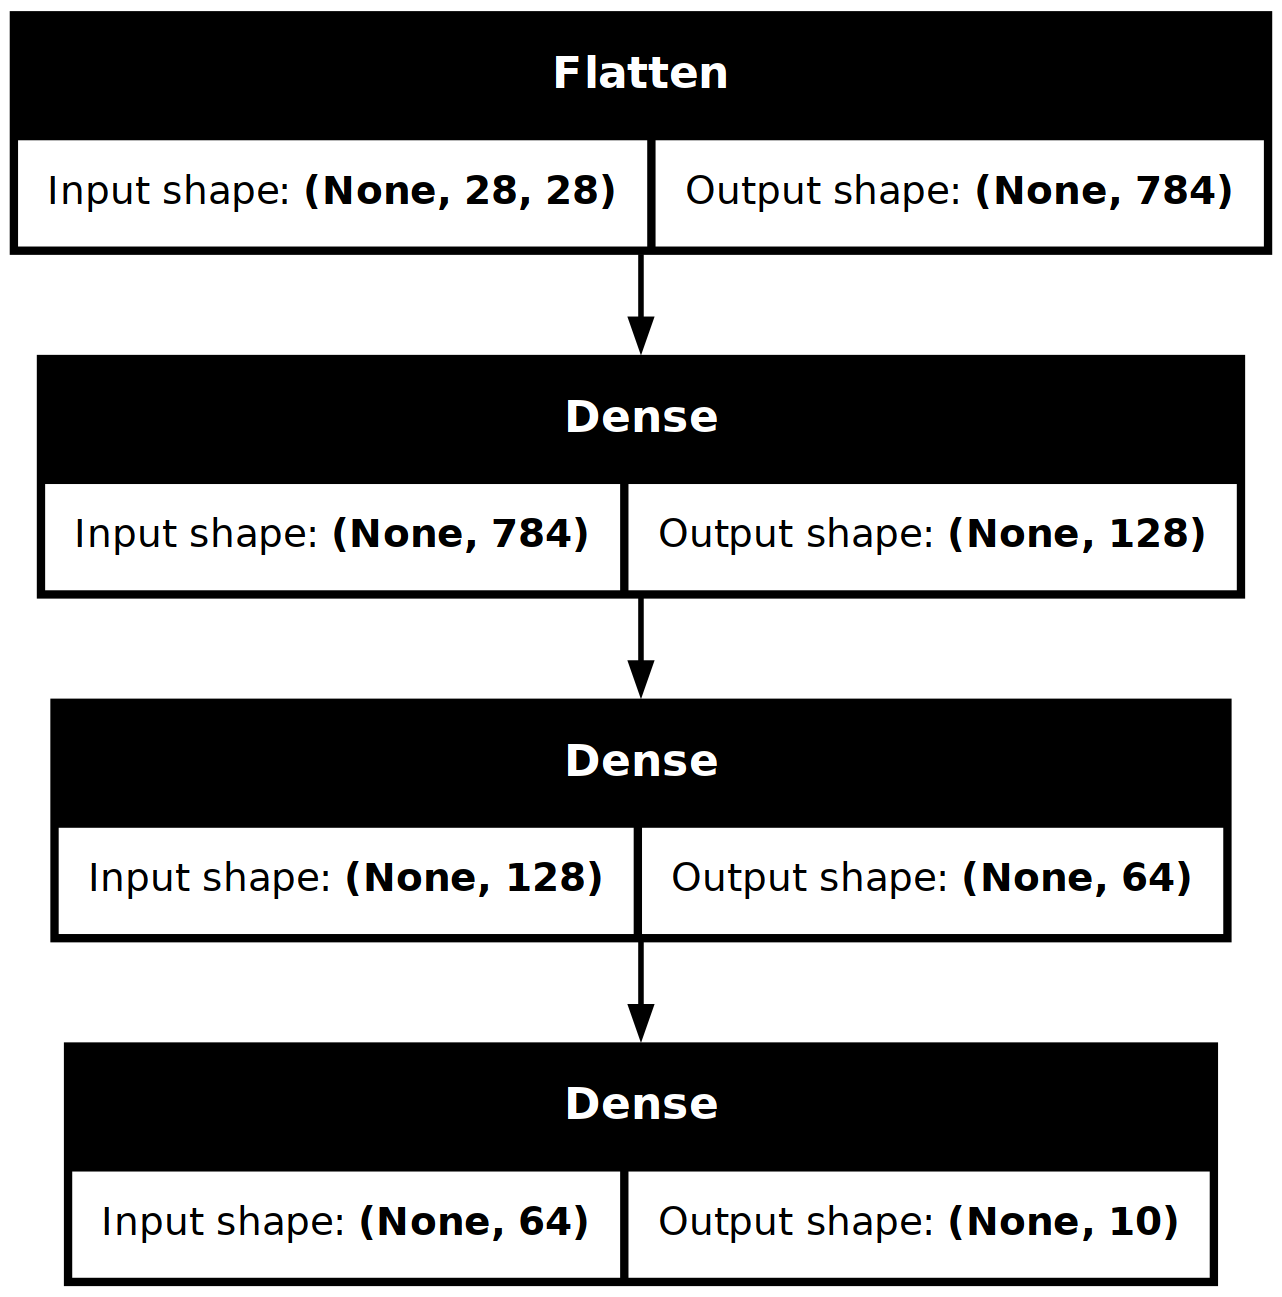

In [90]:
# check out another way of viewing our deep learning models
from tensorflow.keras.utils import plot_model

# see the inputs and outputs of each layer
plot_model(model, show_shapes=True)